## Análise Exploratória dos Dados (EDA)

In [197]:
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import entropy

from sklearn.feature_selection import f_classif, chi2
from sklearn.preprocessing import OrdinalEncoder

In [2]:
BASE_DIR = Path(__name__).resolve().parent.parent

In [3]:
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [19]:
df = pd.read_csv(BASE_DIR / "data/processed/datatran_2022_2026_processed_v1.csv", index_col=0, low_memory=False)

df

,dia_semana,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_meteorologica,tipo_pista,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,data_hora,tr_em_obras,tr_aclive,tr_retorno_regulamentado,tr_viaduto,tr_curva,tr_intersecao_de_vias,tr_reta,tr_tunel,tr_desvio_temporario,tr_rotatoria,tr_ponte,tr_declive,n_caracteristicas_tracado,causa_acidente_grupo,feriado_nacional,estacao,regiao,mes,horario,faixa_km,fim_de_semana
1,sábado,PR,116,33.0,CAMPINA GRANDE DO SUL,Ingestão de álcool pelo condutor,Tombamento,Com Vítimas Fatais,Pleno dia,Decrescente,Nublado,Dupla,Não,3,1,1,0,0,1,1,2,-25.114403,-48.846755,2022-01-01 02:40:00,0,0,0,0,1,0,0,0,0,0,0,0,1,infracao_comportamento_risco,1,Verão,Sul,1,Madrugada,30.0,1
2,sábado,MS,163,393.0,NOVA ALVORADA DO SUL,Condutor deixou de manter distância do veículo...,Colisão traseira,Com Vítimas Feridas,Amanhecer,Decrescente,Céu Claro,Simples,Não,3,0,1,0,1,1,1,3,-21.228445,-54.456296,2022-01-01 05:22:00,0,1,0,0,0,0,0,0,0,0,0,0,1,falha_atencao_reacao,1,Verão,Centro-Oeste,1,Madrugada,390.0,1
3,sábado,RJ,101,457.0,ANGRA DOS REIS,Reação tardia ou ineficiente do condutor,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Sim,2,0,0,1,1,0,1,2,-23.031498,-44.177153,2022-01-01 07:00:00,0,0,0,0,1,0,0,0,0,0,0,0,1,falha_atencao_reacao,1,Verão,Sudeste,1,Manhã,455.0,1
4,sábado,MG,40,508.3,RIBEIRAO DAS NEVES,Acumulo de água sobre o pavimento,Saída de leito carroçável,Sem Vítimas,Pleno dia,Decrescente,Chuva,Dupla,Sim,3,0,0,0,3,0,0,1,-19.760612,-44.134754,2022-01-01 09:00:00,0,0,0,0,0,0,1,0,0,0,0,0,1,condicao_ambiental,1,Verão,Sudeste,1,Manhã,505.0,1
5,sábado,PB,116,8.7,CACHOEIRA DOS INDIOS,Mal súbito do condutor,Colisão com objeto,Sem Vítimas,Pleno dia,Crescente,Céu Claro,Simples,Não,3,0,0,0,2,1,0,2,-6.964668,-38.727608,2022-01-01 09:00:00,0,0,0,0,0,0,1,0,0,0,0,0,1,condicao_saude_condutor,1,Verão,Nordeste,1,Manhã,5.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301527,sexta-feira,PR,277,2.0,CURITIBA,Velocidade Incompatível,Colisão traseira,Com Vítimas Feridas,Plena Noite,Crescente,Nublado,Dupla,Sim,3,0,1,0,2,0,1,2,-25.430412,-49.347344,2026-02-27 22:30:00,0,0,0,0,0,0,1,0,0,0,0,0,1,infracao_comportamento_risco,0,Verão,Sul,2,Noite,0.0,0
301528,sábado,RJ,101,451.9,MANGARATIBA,Reação tardia ou ineficiente do condutor,Colisão frontal,Com Vítimas Feridas,Pleno dia,Crescente,Chuva,Simples,Não,7,0,0,7,0,0,7,2,-23.031173,-44.130535,2026-02-28 09:40:00,0,1,0,0,1,0,0,0,0,0,0,0,2,falha_atencao_reacao,0,Verão,Sudeste,2,Manhã,450.0,1
301529,sexta-feira,BA,101,440.0,UBAITABA,Acessar a via sem observar a presença dos outr...,Colisão transversal,Com Vítimas Feridas,Anoitecer,Crescente,Ignorado,Simples,Não,2,0,0,1,1,0,1,2,-14.266993,-39.326577,2026-04-17 18:00:00,0,0,0,0,0,0,1,0,0,0,0,0,1,falha_atencao_reacao,0,Outono,Nordeste,4,Noite,440.0,0
301530,quinta-feira,MG,381,501.0,BETIM,Reação tardia ou ineficiente do condutor,Engavetamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Dupla,Sim,3,0,1,0,2,0,1,3,-20.007164,-44.215484,2026-04-16 08:15:00,0,0,0,0,0,0,1,0,0,0,0,0,1,falha_atencao_reacao,0,Outono,Sudeste,4,Manhã,500.0,0


In [20]:
pd.set_option("display.max_columns", None)
df.head()

,dia_semana,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_meteorologica,tipo_pista,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,data_hora,tr_em_obras,tr_aclive,tr_retorno_regulamentado,tr_viaduto,tr_curva,tr_intersecao_de_vias,tr_reta,tr_tunel,tr_desvio_temporario,tr_rotatoria,tr_ponte,tr_declive,n_caracteristicas_tracado,causa_acidente_grupo,feriado_nacional,estacao,regiao,mes,horario,faixa_km,fim_de_semana
1,sábado,PR,116,33.0,CAMPINA GRANDE DO SUL,Ingestão de álcool pelo condutor,Tombamento,Com Vítimas Fatais,Pleno dia,Decrescente,Nublado,Dupla,Não,3,1,1,0,0,1,1,2,-25.114403,-48.846755,2022-01-01 02:40:00,0,0,0,0,1,0,0,0,0,0,0,0,1,infracao_comportamento_risco,1,Verão,Sul,1,Madrugada,30.0,1
2,sábado,MS,163,393.0,NOVA ALVORADA DO SUL,Condutor deixou de manter distância do veículo...,Colisão traseira,Com Vítimas Feridas,Amanhecer,Decrescente,Céu Claro,Simples,Não,3,0,1,0,1,1,1,3,-21.228445,-54.456296,2022-01-01 05:22:00,0,1,0,0,0,0,0,0,0,0,0,0,1,falha_atencao_reacao,1,Verão,Centro-Oeste,1,Madrugada,390.0,1
3,sábado,RJ,101,457.0,ANGRA DOS REIS,Reação tardia ou ineficiente do condutor,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Sim,2,0,0,1,1,0,1,2,-23.031498,-44.177153,2022-01-01 07:00:00,0,0,0,0,1,0,0,0,0,0,0,0,1,falha_atencao_reacao,1,Verão,Sudeste,1,Manhã,455.0,1
4,sábado,MG,40,508.3,RIBEIRAO DAS NEVES,Acumulo de água sobre o pavimento,Saída de leito carroçável,Sem Vítimas,Pleno dia,Decrescente,Chuva,Dupla,Sim,3,0,0,0,3,0,0,1,-19.760612,-44.134754,2022-01-01 09:00:00,0,0,0,0,0,0,1,0,0,0,0,0,1,condicao_ambiental,1,Verão,Sudeste,1,Manhã,505.0,1
5,sábado,PB,116,8.7,CACHOEIRA DOS INDIOS,Mal súbito do condutor,Colisão com objeto,Sem Vítimas,Pleno dia,Crescente,Céu Claro,Simples,Não,3,0,0,0,2,1,0,2,-6.964668,-38.727608,2022-01-01 09:00:00,0,0,0,0,0,0,1,0,0,0,0,0,1,condicao_saude_condutor,1,Verão,Nordeste,1,Manhã,5.0,1


In [32]:
df.dtypes

dia_semana                       str
uf                               str
br                             int64
km                           float64
municipio                        str
causa_acidente                   str
tipo_acidente                    str
classificacao_acidente           str
fase_dia                         str
sentido_via                      str
condicao_meteorologica           str
tipo_pista                       str
uso_solo                         str
pessoas                        int64
mortos                         int64
feridos_leves                  int64
feridos_graves                 int64
ilesos                         int64
ignorados                      int64
feridos                        int64
veiculos                       int64
latitude                     float64
longitude                    float64
data_hora                        str
tr_em_obras                    int64
tr_aclive                      int64
tr_retorno_regulamentado       int64
t

## Análise de Desbalanceamento

In [21]:
def plot_dist_var(df: pd.DataFrame, var: str):
    counts = df[var].value_counts()
    percentages = df[var].value_counts(normalize=True) * 100

    ax = sns.barplot(counts)
    plt.title(f"Distribuição da variável {var}")
    
    for i, p in enumerate(ax.patches):
        ax.annotate(f'{int(p.get_height())}\n({percentages.iloc[i]:.1f}%)',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    fontsize=12, color='black', xytext=(0, 15),
                    textcoords='offset points')
    plt.tight_layout()
    plt.show()

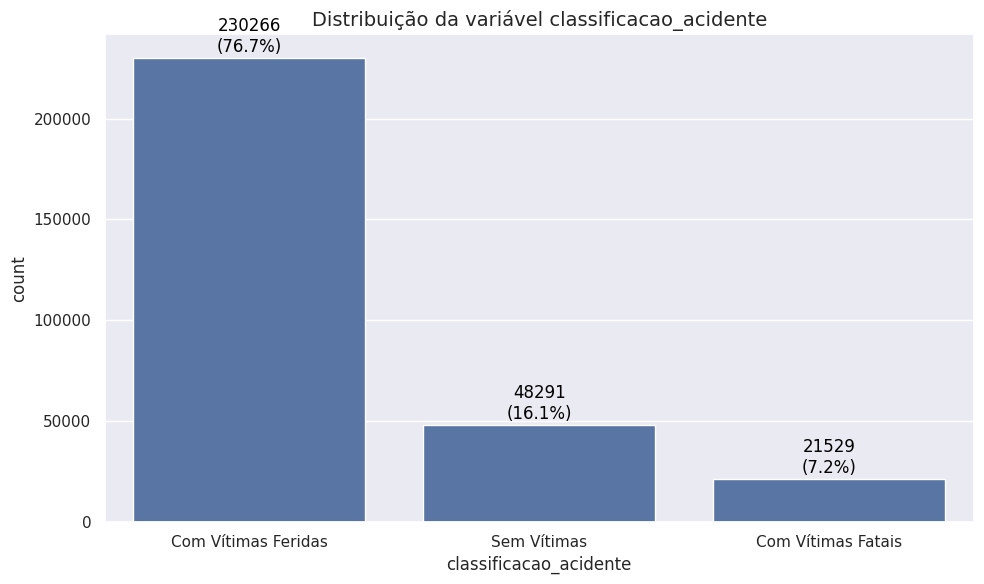

In [22]:
plot_dist_var(df, "classificacao_acidente")

In [23]:
df.columns

Index(['dia_semana', 'uf', 'br', 'km', 'municipio', 'causa_acidente',
       'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via',
       'condicao_meteorologica', 'tipo_pista', 'uso_solo', 'pessoas', 'mortos',
       'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos',
       'veiculos', 'latitude', 'longitude', 'data_hora', 'tr_em_obras',
       'tr_aclive', 'tr_retorno_regulamentado', 'tr_viaduto', 'tr_curva',
       'tr_intersecao_de_vias', 'tr_reta', 'tr_tunel', 'tr_desvio_temporario',
       'tr_rotatoria', 'tr_ponte', 'tr_declive', 'n_caracteristicas_tracado',
       'causa_acidente_grupo', 'feriado_nacional', 'estacao', 'regiao', 'mes',
       'horario', 'faixa_km', 'fim_de_semana'],
      dtype='str')

## Análise Univariada

### Variáveis Numéricas

In [139]:
numericas = ["km", "pessoas", "mortos", "feridos_leves", "feridos_graves", 
"ilesos",  "n_caracteristicas_tracado", "veiculos"]

In [140]:
def extended_numeric_var_describe(df: pd.DataFrame, numeric_cols: list[str]):
    results = df[numeric_cols].describe().T
    results["skewness"] = df[numeric_cols].skew()
    results["kurtosis"] = df[numeric_cols].kurtosis()
    results["zero_pct"] = (df[numericas] == 0).sum() / len(df)

    return results

In [141]:
extended_numeric_var_describe(df, numericas)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,zero_pct
km,300086.0,260.512798,226.723075,0.1,78.3,195.0,408.0,1470.0,0.998435,0.348369,0.000000
pessoas,300086.0,2.596196,2.235205,1.0,2.0,2.0,3.0,95.0,11.274885,231.994707,0.000000
mortos,300086.0,0.083763,0.344831,0.0,0.0,0.0,0.0,37.0,10.802282,572.245538,0.928257
feridos_leves,300086.0,0.874589,1.091273,0.0,0.0,1.0,1.0,83.0,9.960033,336.962677,0.371967
feridos_graves,300086.0,0.279027,0.623141,0.0,0.0,0.0,0.0,35.0,6.437318,163.537104,0.772885
ilesos,300086.0,1.047810,1.767518,0.0,0.0,1.0,1.0,85.0,13.256128,321.322528,0.380827
n_caracteristicas_tracado,300086.0,1.250845,0.499178,1.0,1.0,1.0,1.0,10.0,2.104507,6.067731,0.000000
veiculos,300086.0,1.990646,1.128011,1.0,1.0,2.0,2.0,131.0,8.843928,673.030142,0.000000


A Tabela apresenta as estatísticas descritivas das variáveis numéricas após pré-processamento. Observa-se assimetria positiva severa (skewness > 6,0) em todas as variáveis de contagem de vítimas e veículos, com excesso de curtose superior a 150 em mortos e veiculos, indicando presença de outliers extremos e caudas pesadas. A variável mortos apresenta 92,8% de valores zero, configurando distribuição inflacionada de zeros (zero-inflated), padrão típico de dados de sinistros onde a maioria dos eventos não resulta em óbitos. A média de veiculos (1,99) é ligeiramente inferior à mediana (2,0), porém o desvio padrão (1,13) é mascarado pela concentração em 1–2 veículos, enquanto o valor máximo (131) revela acidentes de engavetamento extremamente raros. Diante da violação sistemática da premissa de normalidade, confirmada pelo QQ-Plot (Figura X) e pelo teste de D'Agostino-Pearson (p < 0,001), a comparação das distribuições numéricas entre as classes de gravidade foi conduzida via teste de Kruskal-Wallis, não-paramétrico e robusto à assimetria e presença de outliers

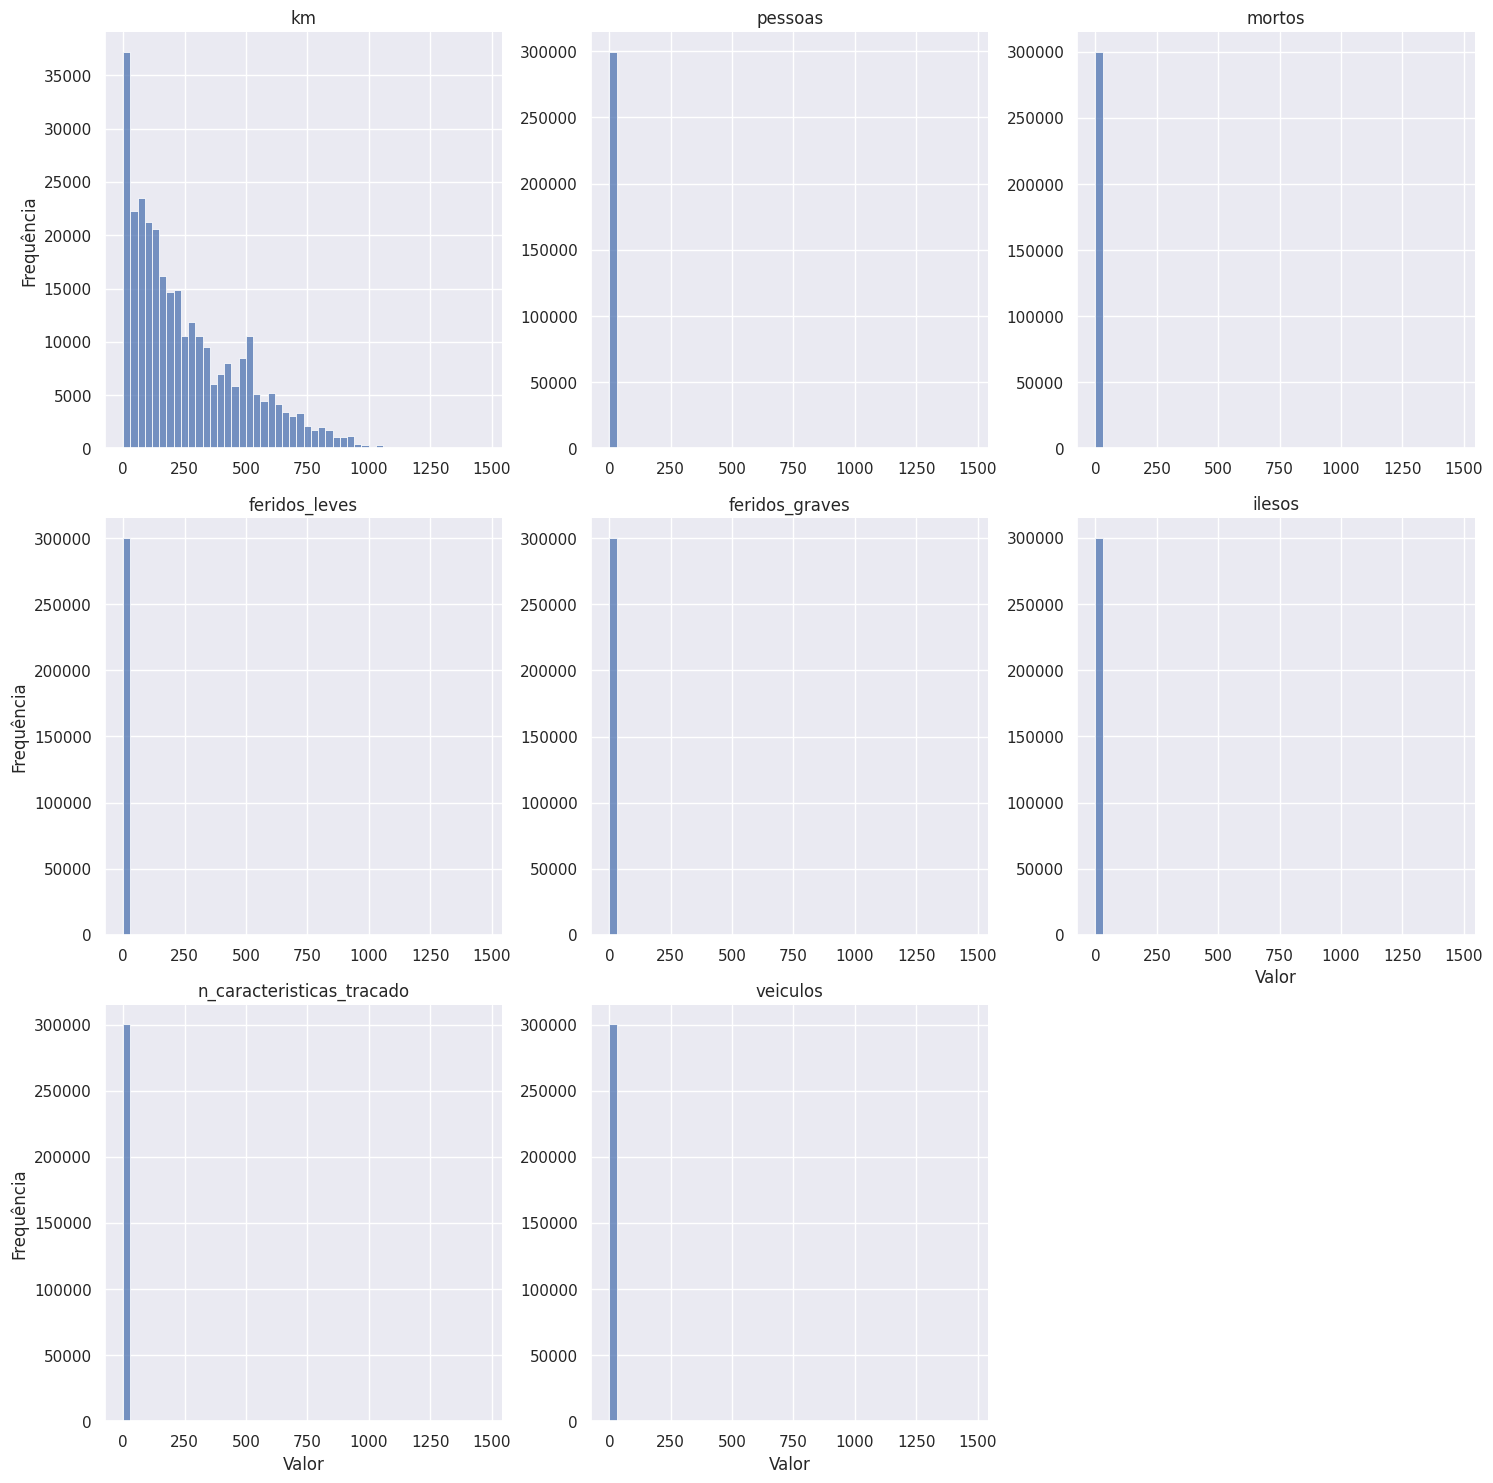

In [154]:
df_long = df[numericas].melt(var_name='variável', value_name='valor')

g = sns.displot(
    data=df_long,
    x="valor",
    col="variável",
    col_wrap=3,
    kind="hist",
    bins=50,
    facet_kws={"sharex": False, "sharey": False}
)

g.set_titles("{col_name}")
g.set_axis_labels("Valor", "Frequência")
plt.show()

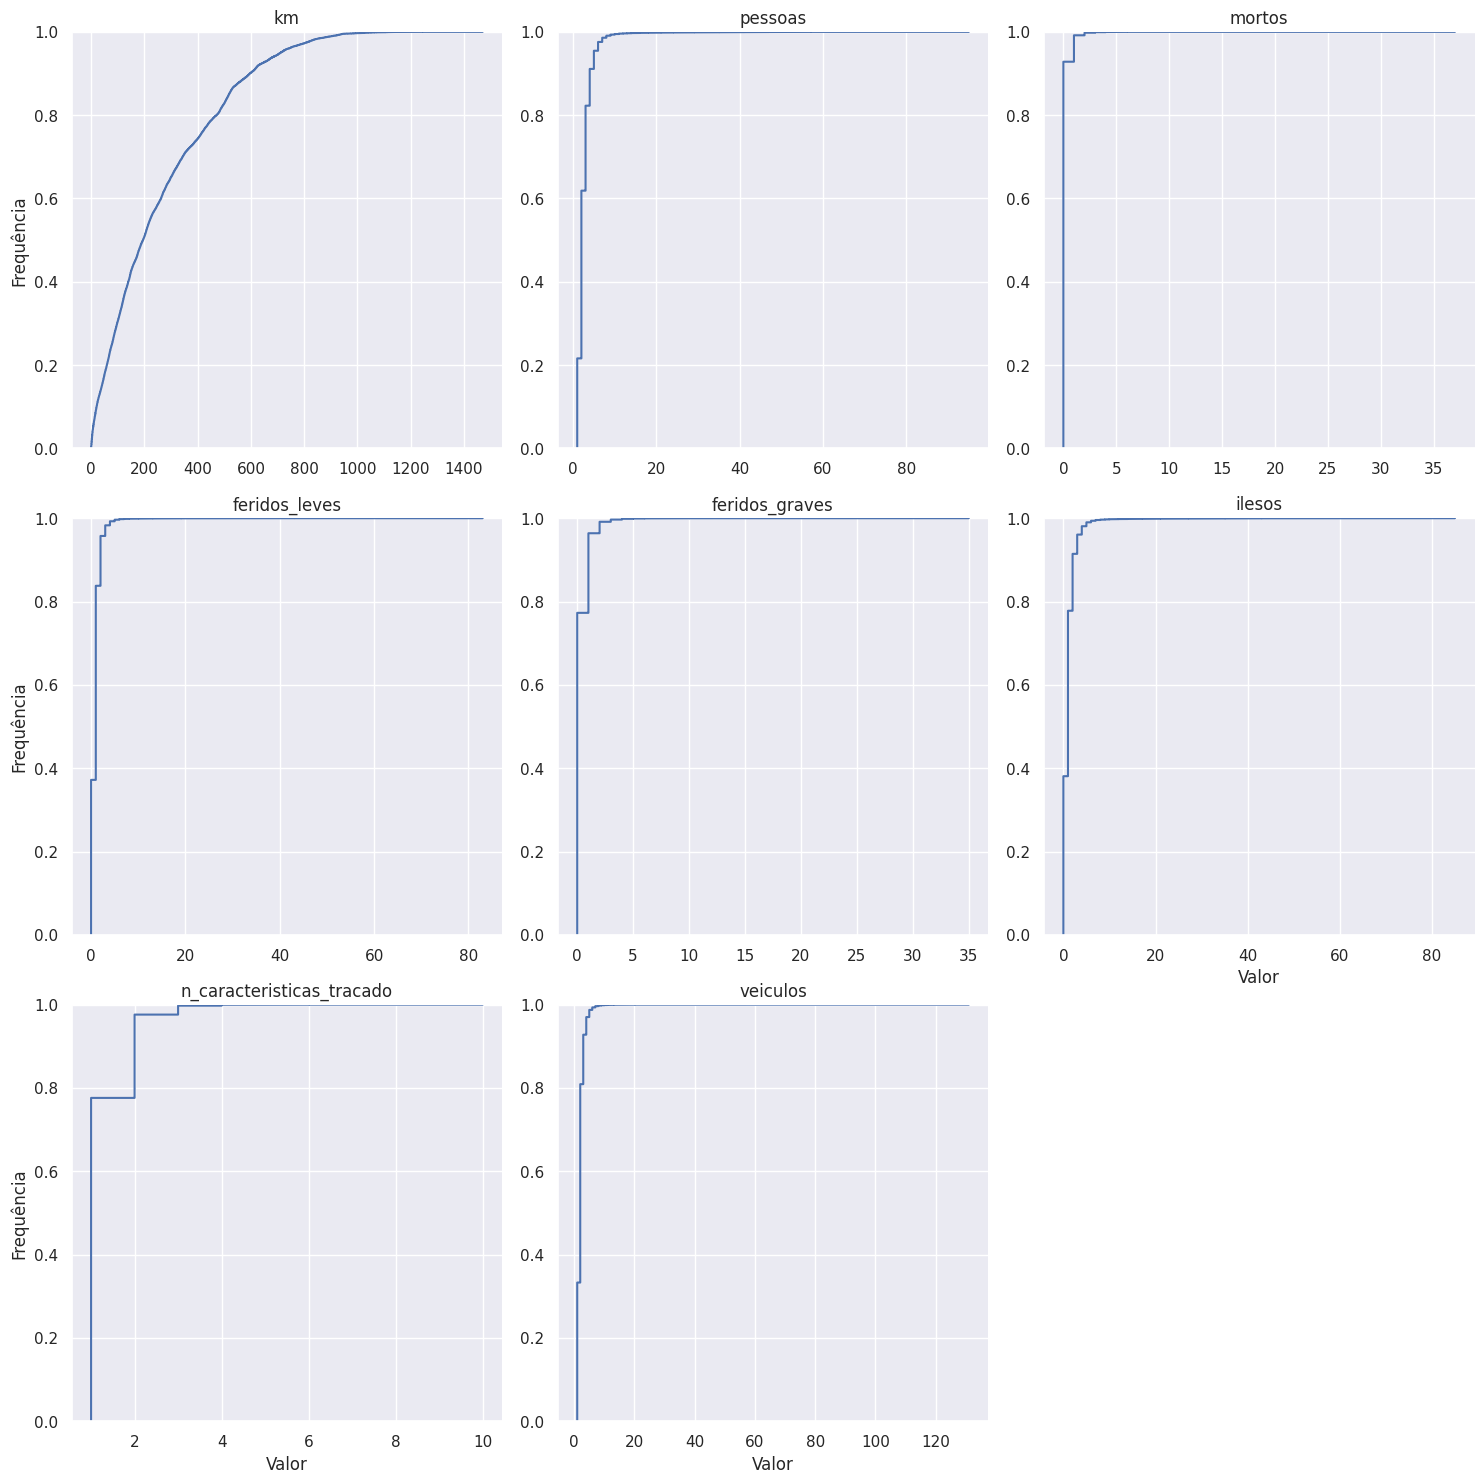

In [157]:
g = sns.displot(
    data=df_long,
    x="valor",
    col="variável",
    col_wrap=3,
    kind="ecdf",
    facet_kws={"sharex": False, "sharey": False}
)

g.set_titles("{col_name}")
g.set_axis_labels("Valor", "Frequência")
plt.show()

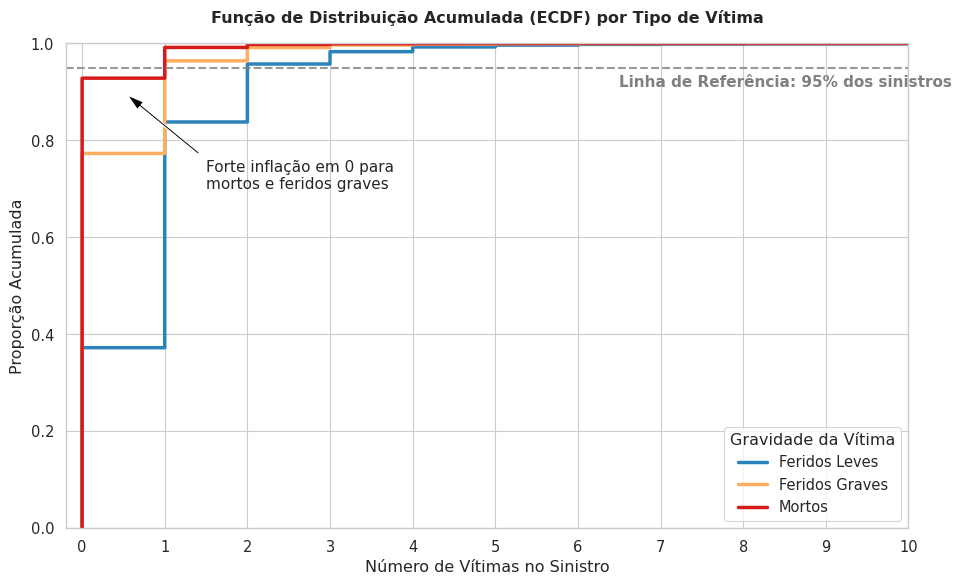

In [181]:
def plot_ecdf_vitimas(df):
    """
    Gera um gráfico ECDF sobrepondo as contagens de vítimas para o artigo.
    """
    # Configuração de estilo limpo (ideal para artigos)
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    
    plt.figure(figsize=(10, 6))
    
    # Plotando as linhas com cores semânticas
    sns.ecdfplot(data=df, x='feridos_leves', label='Feridos Leves', color='#2b83ba', linewidth=2.5)
    sns.ecdfplot(data=df, x='feridos_graves', label='Feridos Graves', color='#fdae61', linewidth=2.5)
    sns.ecdfplot(data=df, x='mortos', label='Mortos', color='#d7191c', linewidth=2.5)
    
    # Adicionando linha de referência no percentil 95% para embasar a explicação
    plt.axhline(y=0.95, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
    plt.text(x=6.5, y=0.91, s='Linha de Referência: 95% dos sinistros', color='gray', fontsize=11, fontweight='bold')
    
    # Adicionando anotação para destacar a inflação de zeros
    plt.annotate('Forte inflação em 0 para \nmortos e feridos graves', 
                 xy=(0.5, 0.90), xytext=(1.5, 0.70),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
                 fontsize=11)

    # Títulos e Eixos
    plt.title('Função de Distribuição Acumulada (ECDF) por Tipo de Vítima', fontweight='bold', pad=15)
    plt.xlabel('Número de Vítimas no Sinistro')
    plt.ylabel('Proporção Acumulada')
    
    # Limitando o eixo X para evitar que outliers extremos (ex: 85 feridos) esmaguem a curva
    plt.xlim(-0.2, 10)
    plt.xticks(np.arange(0, 11, 1))
    
    # Ajustando legenda
    plt.legend(title='Gravidade da Vítima', loc='lower right', frameon=True)
    
    plt.tight_layout()
    plt.show()

plot_ecdf_vitimas(df)

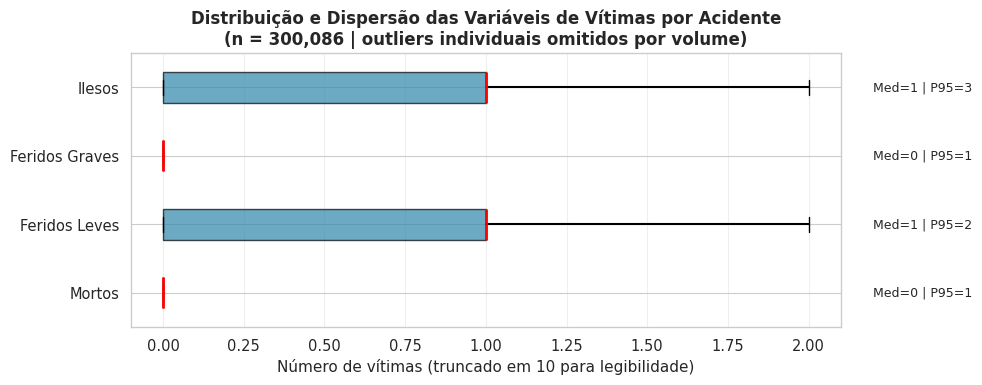

In [190]:
def plot_boxplot_vitimas(df):
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Variáveis de vítimas (zero-inflated, mesma escala 0-10)
    vitimas = ['mortos', 'feridos_leves', 'feridos_graves', 'ilesos']
    data = [df[v].clip(upper=10) for v in vitimas]  # clip em 10 para legibilidade
    
    bp = ax.boxplot(data, tick_labels=['Mortos', 'Feridos Leves', 'Feridos Graves', 'Ilesos'],
                    vert=False, patch_artist=True, showfliers=False,  # SEM outliers individuais
                    medianprops=dict(color='red', linewidth=2),
                    boxprops=dict(facecolor='#2E86AB', alpha=0.7),
                    whiskerprops=dict(color='black', linewidth=1.5))
    
    ax.set_xlabel('Número de vítimas (truncado em 10 para legibilidade)', fontsize=11)
    ax.set_title('Distribuição e Dispersão das Variáveis de Vítimas por Acidente\n' + 
                 f'(n = {len(df):,} | outliers individuais omitidos por volume)', 
                 fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Anota percentis
    for i, v in enumerate(vitimas):
        p50 = df[v].median()
        p95 = df[v].quantile(0.95)
        ax.text(2.2, i+1, f'Med={p50:.0f} | P95={p95:.0f}', va='center', fontsize=9)
    
    plt.tight_layout()
    #plt.savefig('reports/figures/univ_boxplot_vitimas.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_boxplot_vitimas(df)

In [177]:
def plot_qq(df, col, save_path=None):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    data = df[col].dropna()
    stats.probplot(data, dist="norm", plot=ax)
    
    ax.set_title(f'QQ-Plot: {col}\n(Comparação com distribuição Normal)', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    
    # Adiciona texto com estatística de Shapiro-Wilk (amostra pequena) ou D'Agostino
    k2, p = stats.normaltest(data.sample(5000, random_state=42))  # amostra para performance
    ax.text(0.05, 0.95, f"D'Agostino-Pearson:\nK² = {k2:.2f}, p = {p:.4f}", 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

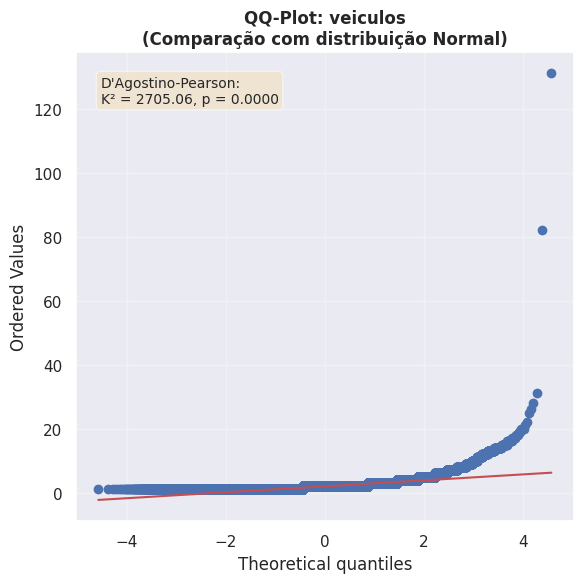

In [178]:
plot_qq(df, 'veiculos')

### Variáveis Categóricas

In [204]:
categoricas = ["classificacao_acidente", "tipo_acidente", "causa_acidente", "causa_acidente_grupo", "tipo_pista", "condicao_meteorologica", 
               "uso_solo", "sentido_via", "regiao", "dia_semana", "estacao", "horario"]

In [206]:
def calcular_imbalance_ratio(df, coluna):
    """Calcula o Imbalance Ratio (IR) clássico (Maior Classe / Menor Classe)."""
    contagens = df[coluna].value_counts()
    n_max = contagens.max()
    n_min = contagens.min()
    return n_max / n_min

def calcular_mean_imbalance_ratio(df, coluna):
    """Calcula o Mean Imbalance Ratio (Mean IR) para cenários multiclasse."""
    contagens = df[coluna].value_counts()
    n_max = contagens.max()
    
    # Calcula o IR de cada classe em relação à classe majoritária
    irs = n_max / contagens
    return irs.mean()

def descricao_categorica(df, col, top_n=10, rare_threshold=0.01):
    """
    Gera estatísticas descritivas univariadas para uma variável categórica.
    Retorna dicionário com métricas e DataFrame de frequências.
    """
    vc = df[col].value_counts()
    vp = df[col].value_counts(normalize=True)
    
    # Entropia (base 2, em bits)
    p = vp.values
    ent = entropy(p, base=2)
    ent_max = np.log2(len(vc))
    ent_norm = ent / ent_max if ent_max > 0 else 0
    
    # Métricas
    stats = {
        'variavel': col,
        'cardinalidade': len(vc),
        'moda': vc.index[0],
        'moda_pct': vp.iloc[0] * 100,
        'entropia': ent,
        'entropia_norm': ent_norm,
        'top3_pct': vp.head(3).sum() * 100,
        'top5_pct': vp.head(5).sum() * 100,
        "Imbalance Ratio (IR)": vp.max() / vp.min(),
        "Mean IR": (vp.max() / vp).mean()
    }
    
    # DataFrame de frequências (top N + demais)
    freq_df = pd.DataFrame({'n': vc, 'pct': vp * 100})
    if len(freq_df) > top_n:
        top = freq_df.head(top_n).copy()
        demais = pd.DataFrame({
            'n': [freq_df.iloc[top_n:]['n'].sum()],
            'pct': [freq_df.iloc[top_n:]['pct'].sum()]
        }, index=[f'Demais (n={len(freq_df)-top_n})'])
        freq_df = pd.concat([top, demais])
    
    return stats, freq_df

In [201]:
descricao_categorica(df, "classificacao_acidente")

({'variavel': 'classificacao_acidente',
  'cardinalidade': 3,
  'moda': 'Com Vítimas Feridas',
  'moda_pct': np.float64(76.73333644355284),
  'entropia': np.float64(0.989997352966714),
  'entropia_norm': np.float64(0.624618785943684),
  'top3_pct': np.float64(100.0),
  'top5_pct': np.float64(100.0),
  'n_raras_lt_1pct': np.int64(0),
  'n_raras_lt_0.1pct': np.int64(0),
  'pct_raras_lt_1pct': np.float64(0.0)},
                              n        pct
 classificacao_acidente                   
 Com Vítimas Feridas     230266  76.733336
 Sem Vítimas              48291  16.092387
 Com Vítimas Fatais       21529   7.174277)

In [207]:
resumo_cat = []
for col in categoricas:
    if col in df.columns:
        stats, freq = descricao_categorica(df, col, top_n=10)
        resumo_cat.append(stats)

pd.DataFrame(resumo_cat)

,variavel,cardinalidade,moda,moda_pct,entropia,entropia_norm,top3_pct,top5_pct,Imbalance Ratio (IR),Mean IR
0,classificacao_acidente,3,Com Vítimas Feridas,76.733336,0.989997,0.624619,100.000000,100.000000,10.695620,5.487973
1,tipo_acidente,17,Colisão traseira,19.212826,3.462233,0.847037,46.888559,66.030405,2620.681818,167.730670
2,causa_acidente,76,Reação tardia ou ineficiente do condutor,14.413868,4.497619,0.719858,37.961451,50.516519,4806.000000,347.147273
3,causa_acidente_grupo,8,falha_atencao_reacao,53.616630,1.948471,0.649490,86.152636,93.499197,54.301721,16.796326
4,tipo_pista,3,Simples,48.595736,1.353325,0.853853,100.000000,100.000000,5.141704,2.433347
5,condicao_meteorologica,10,Céu Claro,62.639710,1.737957,0.523177,88.436315,97.701326,31328.833333,5278.054999
6,uso_solo,2,Não,57.153616,0.985183,0.985183,100.000000,100.000000,1.333919,1.166960
7,sentido_via,2,Crescente,53.847230,0.995725,0.995725,100.000000,100.000000,1.166717,1.083359
8,regiao,5,Sudeste,31.487973,2.115919,0.911277,82.714289,100.000000,5.841793,2.400536
9,dia_semana,7,domingo,16.300327,2.799093,0.997057,47.900269,74.821218,1.312344,1.154076


In [208]:
def plot_barra_categorica(freq_df, titulo, save_path=None, horizontal=False, 
                          color='#2E86AB', figsize=(10, 5)):
    """
    Plota barras de frequência/proporção para variável categórica.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    labels = freq_df.index.astype(str)
    valores = freq_df['pct'].values
    
    if horizontal:
        bars = ax.barh(np.arange(len(labels)), valores, color=color, 
                       edgecolor='black', linewidth=0.5, alpha=0.85)
        ax.set_yticks(np.arange(len(labels)))
        ax.set_yticklabels(labels, fontsize=10)
        ax.set_xlabel('Proporção (%)', fontsize=11)
        ax.invert_yaxis()  # maior no topo
    else:
        bars = ax.bar(np.arange(len(labels)), valores, color=color,
                      edgecolor='black', linewidth=0.5, alpha=0.85)
        ax.set_xticks(np.arange(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
        ax.set_ylabel('Proporção (%)', fontsize=11)
    
    # Valores sobre as barras
    for bar, val in zip(bars, valores):
        if horizontal:
            ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
                    f'{val:.1f}%', va='center', fontsize=9)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                    f'{val:.1f}%', ha='center', fontsize=9)
    
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.grid(axis='x' if horizontal else 'y', alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

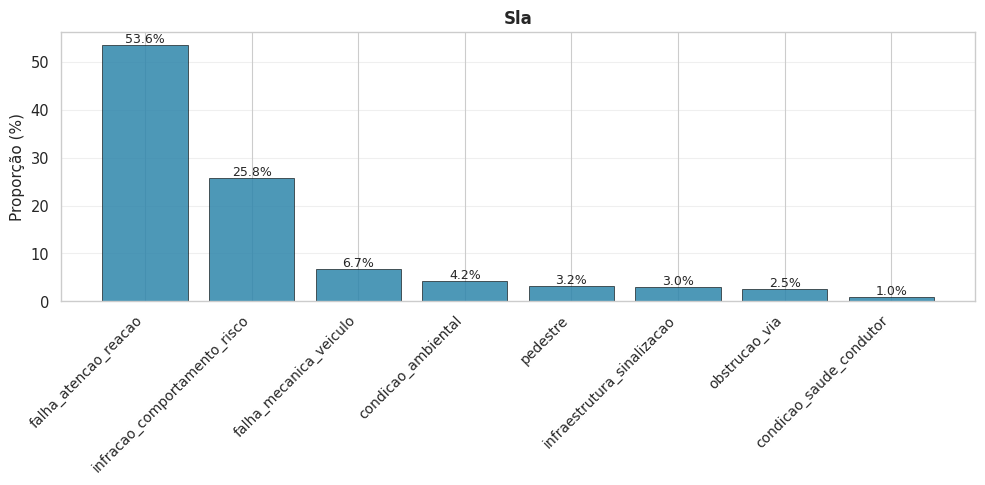

In [211]:
plot_barra_categorica(descricao_categorica(df, "causa_acidente_grupo")[1], "Sla")

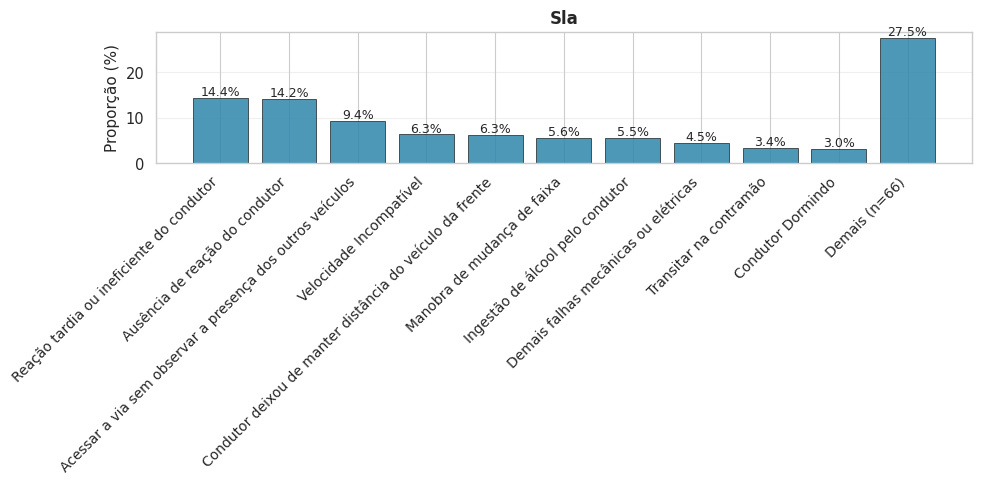

In [212]:
plot_barra_categorica(descricao_categorica(df, "causa_acidente")[1], "Sla")

### Variáveis Binárias Multilabel

Análise das variáveis descendentes de `tracado_via`

In [213]:
cols_tr = [c for c in df.columns if c.startswith('tr_')]

<Axes: >

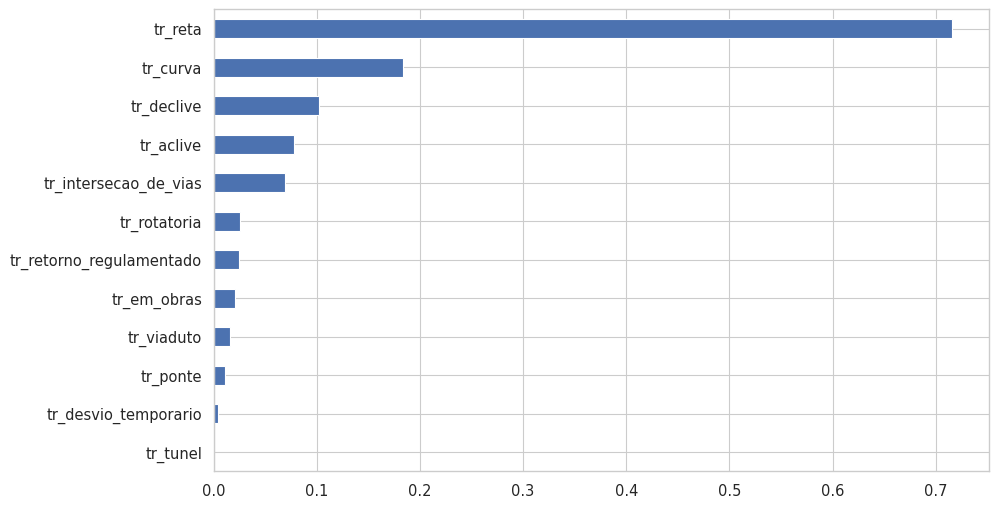

In [214]:
df[cols_tr].mean().sort_values().plot(kind='barh')

In [215]:
(df.groupby(df[cols_tr].any(axis=1))  # exemplo para qualquer tr_
   ['classificacao_acidente']
   .apply(lambda x: (x == 'Com Vítimas Fatais').mean()))

# Melhor: para cada feature individualmente
{col: df[df[col]==1]['classificacao_acidente']
       .eq('Com Vítimas Fatais').mean()
 for col in cols_tr}

{'tr_em_obras': np.float64(0.06416175768189779),
 'tr_aclive': np.float64(0.08824406664110103),
 'tr_retorno_regulamentado': np.float64(0.03334248079034029),
 'tr_viaduto': np.float64(0.04087530966143683),
 'tr_curva': np.float64(0.08008995611012369),
 'tr_intersecao_de_vias': np.float64(0.03519899293115135),
 'tr_reta': np.float64(0.0740559645716042),
 'tr_tunel': np.float64(0.0449438202247191),
 'tr_desvio_temporario': np.float64(0.05622188905547226),
 'tr_rotatoria': np.float64(0.02213973220204163),
 'tr_ponte': np.float64(0.10344827586206896),
 'tr_declive': np.float64(0.09889142484512553)}

In [217]:
comatriz = df[cols_tr].T.dot(df[cols_tr])
comatriz

,tr_em_obras,tr_aclive,tr_retorno_regulamentado,tr_viaduto,tr_curva,tr_intersecao_de_vias,tr_reta,tr_tunel,tr_desvio_temporario,tr_rotatoria,tr_ponte,tr_declive
tr_em_obras,6281,489,141,178,771,534,4447,15,854,171,142,740
tr_aclive,489,23469,362,653,5562,789,13384,11,93,149,132,0
tr_retorno_regulamentado,141,362,7288,223,778,961,3335,18,30,313,15,524
tr_viaduto,178,653,223,4844,902,744,1763,19,33,280,29,603
tr_curva,771,5562,778,902,55138,1555,0,44,226,490,360,10382
tr_intersecao_de_vias,534,789,961,744,1555,20654,8922,33,93,1460,41,1092
tr_reta,4447,13384,3335,1763,0,8922,214743,83,631,1292,2012,14653
tr_tunel,15,11,18,19,44,33,83,178,10,8,6,27
tr_desvio_temporario,854,93,30,33,226,93,631,10,1334,31,39,136
tr_rotatoria,171,149,313,280,490,1460,1292,8,31,7543,10,217


## Teste de Associação com Variável Alvo

In [78]:
def rank_categorical_features(
    df: pd.DataFrame, 
    categorical_cols: list[str], 
    target_col: str
) -> pd.DataFrame:
    """
    Realiza o teste Qui-Quadrado de independência e calcula o V de Cramér para 
    medir a força da associação entre variáveis categóricas e a variável alvo.

    :param df: DataFrame contendo os dados analisados.
    :type df: pd.DataFrame
    :param categorical_cols: Lista de strings com os nomes das colunas categóricas.
    :type categorical_cols: List[str]
    :param target_col: Nome da coluna alvo (ex: 'classificacao_acidente').
    :type target_col: str
    :return: DataFrame ranqueado em ordem decrescente pela força da associação (Cramér's V).
    :rtype: pd.DataFrame
    """
    results = []

    def cohen_class_cramers_v(v, df):
        """Classificação do V de Cramér feita por Cohen, baseada no
        grau de liberdade"""
        s = np.sqrt(df)
        if v < 0.10/s: return 'Negligenciável'
        elif v < 0.30/s: return 'Fraca'
        elif v < 0.50/s: return 'Moderada'
        else: return 'Forte'

    for col in categorical_cols:
        contingency_table = pd.crosstab(df[col], df[target_col])
        chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
        
        # Cálculo do V de Cramér com correção de viés (Bias Correction)
        n = contingency_table.sum().sum()
        phi2 = chi2 / n
        r, k = contingency_table.shape
        
        phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
        rcorr = r - ((r - 1) ** 2) / (n - 1)
        kcorr = k - ((k - 1) ** 2) / (n - 1)
        
        cramers_v = np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1))) if min((kcorr - 1), (rcorr - 1)) > 0 else 0.0

        class_v = cohen_class_cramers_v(cramers_v, min(r-1, k-1))

        results.append({
            'feature': col,
            'chi2_statistic': chi2,
            'p_value': p_val,
            'cramers_v': cramers_v,
            "interpretacao": class_v
        })

    ranking_df = pd.DataFrame(results)
    return ranking_df.sort_values(by='cramers_v', ascending=False).reset_index(drop=True)

In [79]:
rank_categorical_features(df, categoricas, "classificacao_acidente")

,feature,chi2_statistic,p_value,cramers_v,interpretacao
0,tipo_acidente,71282.332936,0.000000e+00,0.344554,Moderada
1,causa_acidente_grupo,20180.767484,0.000000e+00,0.183308,Fraca
2,horario,6199.538886,0.000000e+00,0.101586,Fraca
3,uso_solo,2854.185089,0.000000e+00,0.097491,Negligenciável
4,regiao,3410.345699,0.000000e+00,0.075293,Fraca
5,tipo_pista,3233.600808,0.000000e+00,0.073356,Fraca
6,dia_semana,1325.228848,1.822299e-276,0.046777,Negligenciável
7,condicao_meteorologica,587.250563,4.255416e-113,0.030797,Negligenciável
8,sentido_via,37.552725,7.006954e-09,0.010885,Negligenciável
9,estacao,34.124837,6.364097e-06,0.006846,Negligenciável


In [110]:
def rank_numerical_features(
    df: pd.DataFrame, 
    numerical_cols: list[str], 
    target_col: str
) -> pd.DataFrame:
    """
    Aplica o teste não paramétrico de Kruskal-Wallis para verificar se as distribuições 
    das variáveis numéricas diferem significativamente entre as classes da variável alvo.

    :param df: DataFrame contendo os dados analisados.
    :type df: pd.DataFrame
    :param numerical_cols: Lista de strings com os nomes das colunas numéricas.
    :type numerical_cols: List[str]
    :param target_col: Nome da coluna alvo.
    :type target_col: str
    :return: DataFrame ranqueado em ordem decrescente pela Estatística H do teste.
    :rtype: pd.DataFrame
    """
    results = []
    # Agrupa os dados pelo target uma única vez para otimização
    grouped = df.groupby(target_col)
    n_total = len(df)
    
    for col in numerical_cols:
        # Extrai os arrays numéricos para cada categoria do target, removendo nulos
        samples = [group[col].dropna().values for _, group in grouped]
        
        # Exige pelo menos duas classes com variação de dados para o teste
        if len(samples) > 1 and all(len(s) > 0 for s in samples):
            h_stat, p_val = stats.kruskal(*samples)
            epsilon_squared = h_stat / ((n_total ** 2 - 1) / (n_total + 1))
        else:
            h_stat, p_val, epsilon_squared = np.nan, np.nan, np.nan

        # TODO: adicionar eta squared ou epsilon squared

        results.append({
            'feature': col,
            'h_statistic': h_stat,
            'p_value': p_val,
            "epsilon²": epsilon_squared
        })

    ranking_df = pd.DataFrame(results)
    return ranking_df.sort_values(by='h_statistic', ascending=False).reset_index(drop=True)

In [111]:
numeric_validation_cols = ["veiculos", "n_caracteristicas_tracado"]

rank_numerical_features(df, numeric_validation_cols, "classificacao_acidente")

,feature,h_statistic,p_value,epsilon²
0,veiculos,5522.427003,0.000000e+00,0.018403
1,n_caracteristicas_tracado,171.253304,6.498566e-38,0.000571


In [114]:
df[df["tr_tunel"] == 1].shape

(178, 45)

In [195]:
def rank_binary_features(
    df: pd.DataFrame, 
    binary_cols: list[str],
    target_col: str,
    positive_class: str
) -> pd.DataFrame:
    """
    Calcula a Razão de Chances (Odds Ratio) para variáveis binárias em relação a um 
    desfecho específico da variável alvo, aplicando a correção de Haldane-Anscombe.

    :param df: DataFrame contendo os dados analisados.
    :type df: pd.DataFrame
    :param binary_cols: Lista de strings com os nomes das colunas binárias (valores 0 e 1).
    :type binary_cols: List[str]
    :param target_col: Nome da coluna alvo.
    :type target_col: str
    :param positive_class: Valor da classe alvo considerada como evento de interesse.
    :type positive_class: str
    :return: DataFrame ranqueado em ordem decrescente pelo Odds Ratio.
    :rtype: pd.DataFrame
    """
    results = []
    
    # Binariza o target: 1 se for a classe positiva (ex: Vítimas Fatais), 0 caso contrário
    is_positive_event = (df[target_col] == positive_class).astype(int)
    
    for col in binary_cols:
        contingency = pd.crosstab(df[col], is_positive_event)
        
        # Garante a estrutura 2x2 preenchendo ausências com 0
        contingency = contingency.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
        
        # Células da matriz de confusão
        true_negative = contingency.loc[0, 0]  # feature = 0, target = 0
        false_positive = contingency.loc[1, 0] # feature = 1, target = 0
        false_negative = contingency.loc[0, 1] # feature = 0, target = 1
        true_positive = contingency.loc[1, 1]  # feature = 1, target = 1
        
        # Correção de Haldane-Anscombe (+0.5 em todas as células se houver algum zero)
        if 0 in [true_negative, false_positive, false_negative, true_positive]:
            true_negative += 0.5
            false_positive += 0.5
            false_negative += 0.5
            true_positive += 0.5
            
        # Cálculo: (A/B) / (C/D) -> (TP * TN) / (FP * FN)
        odds_ratio = (true_positive * true_negative) / (false_positive * false_negative)

        log_or = np.log(odds_ratio)
        se_log_or = np.sqrt(1/true_positive + 1/false_negative +
                            1/false_positive + 1/true_negative)
        ci_low  = np.exp(log_or - 1.96 * se_log_or)
        ci_high = np.exp(log_or + 1.96 * se_log_or)
        significativa = not (ci_low <= 1.0 <= ci_high)
        
        results.append({
            'feature': col,
            'odds_ratio': odds_ratio,
            'IC 95%': f"[{ci_low:.3f}, {ci_high:.3f}]",
            "significativa": significativa
        })

    

    ranking_df = pd.DataFrame(results).sort_values(by='odds_ratio', ascending=False).reset_index(drop=True)
    return ranking_df

In [193]:
binary_features = [
    'fim_de_semana', 'feriado_nacional', 'tr_reta', 'tr_curva', 
    'tr_aclive', 'tr_declive', 'tr_intersecao_de_vias', 'tr_rotatoria', 
    'tr_viaduto', 'tr_ponte', 'tr_tunel', 'tr_em_obras', 
    'tr_retorno_regulamentado', 'tr_desvio_temporario'
]

In [196]:
rank_binary_features(df, binary_features, "classificacao_acidente", "Com Vítimas Fatais")

,feature,odds_ratio,IC 95%,significativa
0,tr_ponte,1.500670,"[1.339, 1.682]",True
1,tr_declive,1.488809,"[1.430, 1.550]",True
2,tr_aclive,1.279118,"[1.220, 1.341]",True
3,fim_de_semana,1.278835,"[1.243, 1.316]",True
4,tr_curva,1.159116,"[1.120, 1.200]",True
5,tr_reta,1.133252,"[1.098, 1.170]",True
6,feriado_nacional,1.105035,"[1.027, 1.189]",True
7,tr_em_obras,0.884932,"[0.799, 0.980]",True
8,tr_desvio_temporario,0.769970,"[0.610, 0.972]",True
9,tr_tunel,0.608734,"[0.300, 1.237]",False


## Análise Multivariada

In [ ]:
def plot_boxplot_bivariado(df, numerica_col='pessoas'):
    """
    Gera um boxplot condicional relacionando uma variável de contagem com a classificação do acidente.
    """
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    
    plt.figure(figsize=(10, 6))
    
    # Criando o boxplot
    # fliersize=4 ajusta o tamanho dos pontos de outliers para não poluírem muito a visão
    ax = sns.boxplot(
        data=df, 
        x='classificacao_acidente', 
        y=numerica_col, 
        palette='Set2',
        linewidth=1.5,
        fliersize=4
    )
    
    # Aplicando escala logarítmica simétrica no eixo Y (útil para lidar com assimetria extrema)
    # Obs: Se numerica_col for 'veiculos' ou 'pessoas', o min é 1, então log10 normal funciona bem.
    ax.set_yscale('log')
    
    # Títulos e Eixos
    col_name_formatted = numerica_col.capitalize()
    plt.title(f'Dispersão de {col_name_formatted} Envolvidas vs. Gravidade do Sinistro', fontweight='bold', pad=15)
    plt.xlabel('Classificação do Acidente (Variável Alvo)')
    
    # Subtítulo no eixo Y para avisar a banca sobre a escala
    plt.ylabel(f'Total de {col_name_formatted} (Escala Logarítmica)')
    
    # Formatando as marcações do eixo Y para não aparecerem em notação científica (10^0, 10^1)
    from matplotlib.ticker import ScalarFormatter
    ax.yaxis.set_major_formatter(ScalarFormatter())
    
    plt.tight_layout()
    plt.show()